In [7]:
!pip install tensorflow opencv-python scikit-learn gradio -q
import tensorflow as tf
print(tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
from google.colab import files
uploaded = files.upload()

Saving rosacea-nose-2.jpg to rosacea-nose-2 (1).jpg
Saving rosacea-nose-3.jpg to rosacea-nose-3.jpg
Saving rosacea-nose-4.jpg to rosacea-nose-4.jpg
Saving rosacea-nose-5.jpg to rosacea-nose-5 (1).jpg
Saving rosacea-nose-6.jpg to rosacea-nose-6 (1).jpg
Saving rosacea-nose-7.jpg to rosacea-nose-7 (1).jpg
Saving rosacea-nose-8.jpg to rosacea-nose-8.jpg
Saving rosacea-nose-9.jpg to rosacea-nose-9.jpg
Saving rosacea-nose-21.jpg to rosacea-nose-21.jpg
Saving rosacea-nose-22.jpg to rosacea-nose-22.jpg
Saving rosacea-nose-23.jpg to rosacea-nose-23.jpg
Saving rosacea-nose-24.jpg to rosacea-nose-24 (1).jpg
Saving rosacea-nose-25.jpg to rosacea-nose-25.jpg
Saving rosacea-nose-26.jpg to rosacea-nose-26.jpg
Saving rosacea-nose-28.jpg to rosacea-nose-28.jpg
Saving rosacea-nose-29.jpg to rosacea-nose-29 (1).jpg
Saving rosacea-nose-30.jpg to rosacea-nose-30 (1).jpg
Saving rosacea-nose-31.jpg to rosacea-nose-31.jpg
Saving rosacea-nose-32.jpg to rosacea-nose-32.jpg
Saving rosacea-nose-33.jpg to rosacea-

In [11]:
import os
files_list = [f for f in os.listdir('.') if f.endswith('.jpg') or f.endswith('.png')]
print("Total images:", len(files_list))
print(files_list[:10])

Total images: 1152
['rosacea-nose-47.jpg', 'rosacea-32.jpg', 'acne-cystic-151.jpg', 'hidradenitis-suppurativa-84.jpg', 'acne-cystic-146.jpg', 'hidradenitis-suppurativa-41.jpg', 'hidradenitis-suppurativa-6.jpg', 'acne-pustular-7 (1).jpg', 'acne-cystic-128.jpg', '07rhnophymas0321051 (1).jpg']


In [12]:
import pandas as pd
import re

def extract_label(filename):
    # Remove file extension and trailing numbers
    name = filename.rsplit('.', 1)[0]
    name = re.sub(r'-?\d+$', '', name)  # remove trailing numbers like -47, -32
    return name

data = []
for f in files_list:
    label = extract_label(f)
    data.append({'filename': f, 'label': label})

df = pd.DataFrame(data)
print("Unique classes:", df['label'].nunique())
print(df['label'].value_counts())

Unique classes: 330
label
acne-cystic                        123
rosacea                            117
perioral-dermatitis                115
hidradenitis-suppurativa           100
acne-open-comedo                    72
                                  ... 
acne-cystic-45 (1)                   1
rosacea-68 (1)                       1
acne-open-comedo-33 (1)              1
perioral-dermatitis-33 (1)           1
hidradenitis-suppurativa-25 (1)      1
Name: count, Length: 330, dtype: int64


In [13]:
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 64  # keep small for speed given limited images

X = []
y = []

for idx, row in df.iterrows():
    img = cv2.imread(row['filename'])
    if img is not None:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        y.append(row['label'])

X = np.array(X) / 255.0
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

print("X shape:", X.shape)
print("Num classes:", num_classes)
print("Classes:", le.classes_)

X shape: (1152, 64, 64, 3)
Num classes: 330
Classes: ['07Acne' '07AcnePittedScars' '07PerioralDermEye' '07PerioralDermEye (1)'
 '07PerioralDermNose' '07PerioralDermq' '07PerioralSteroid'
 '07PerlecheAccutane' '07Rhinophyma' '07Rhinophyma1 (1)' '07Rhinophyma1a'
 '07Rhinophymaq' '07RosaceaForehead' '07RosaceaFulFAce'
 '07RosaceaFulFAce (1)' '07RosaceaK' '07RosaceaMilia'
 '07RosaceaMilia0120 (1)' '07RosaceaOK' '07RosaceaOK0828063 (1)'
 '07RosaceaTel' '07SteroidPerioral' '07SteroidPerioral (1)'
 '07SteroidRosGlab' '07SteroidRosacea' '07VascularFace'
 '07VascularFace0120 (1)' '07rhnophymas' '07rhnophymas0321051 (1)'
 '07rosacea010206OK' '07rosaceaTreated091806OK' '07sebDerem'
 '07sebDerem1101051 (1)' '08PerioralDerm' '08PerioralDerm1 (1)'
 '23VesselsNose' 'Comedones-Ears' 'ComedonesEars' 'ComedonesEars-1 (1)'
 'Forest' 'Forest-2 (1)' 'Hidradenitis-Suppurativa-Areola'
 'Hidradenitis-Suppurativa-Areola-2 (1)' 'Sebaceous-glands-Areola'
 'Sebaceous-glands-labia' 'acne-Closed-Comedo' 'acne-close

In [14]:
from collections import Counter

# Count samples per class
class_counts = Counter(y)
valid_classes = [cls for cls, count in class_counts.items() if count >= 5]

# Keep only rows with valid classes
mask = [label in valid_classes for label in y]
X_filtered = X[np.array(mask)]
y_filtered = [label for label, m in zip(y, mask) if m]

y_encoded_filtered = le.fit_transform(y_filtered)
num_classes = len(le.classes_)

print("Classes after filtering:", num_classes)
print("Total images after filtering:", len(X_filtered))

Classes after filtering: 20
Total images after filtering: 824


In [15]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(y_encoded_filtered, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_cat, test_size=0.2, random_state=42, stratify=y_encoded_filtered
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (659, 64, 64, 3) Test: (165, 64, 64, 3)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # auto-matches your class count
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,676 (2.62 MB)

 Trainable params: 686,228 (2.62 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
from sklearn.utils.class_weight import compute_class_weight

# Class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded_filtered),
    y=y_encoded_filtered
)
class_weights_dict = dict(enumerate(class_weights))

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict
)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 367ms/step - accuracy: 0.1002 - loss: 5.0365 - val_accuracy: 0.1152 - val_loss: 2.8667
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.1320 - loss: 2.9478 - val_accuracy: 0.0364 - val_loss: 2.9647
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2018 - loss: 2.5168 - val_accuracy: 0.0909 - val_loss: 3.9290
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1927 - loss: 2.2344 - val_accuracy: 0.0970 - val_loss: 3.5734
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2519 - loss: 2.0510 - val_accuracy: 0.0909 - val_loss: 5.0237
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2686 - loss: 1.7282 - val_accuracy: 0.0909 - val_loss: 5.8471
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3141 - loss: 1.5794 - val_accuracy: 0.0909 - val_loss: 6.0096
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3475 - loss: 1.5231 - val_accuracy: 0.0909 -

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step
                          precision    recall  f1-score   support

              07RosaceaK       0.00      0.00      0.00         1
      acne-closed-comedo       0.00      0.00      0.00         8
             acne-cystic       0.57      0.16      0.25        25
         acne-excoriated       0.00      0.00      0.00         6
          acne-infantile       0.00      0.00      0.00         3
        acne-open-comedo       0.06      0.20      0.10        15
     acne-primary-lesion       1.00      1.00      1.00         1
           acne-pustular       0.38      0.21      0.27        14
               acne-scar       0.00      0.00      0.00         2
           fordyce-spots       0.00      0.00      0.00         1
hidradenitis-suppurativa       0.22      0.70      0.33        20
           hyperhidrosis       0.00      0.00      0.00         1
                   milia       0.00      0.00      0.00         3
minocycline-pigmentation       0.00 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


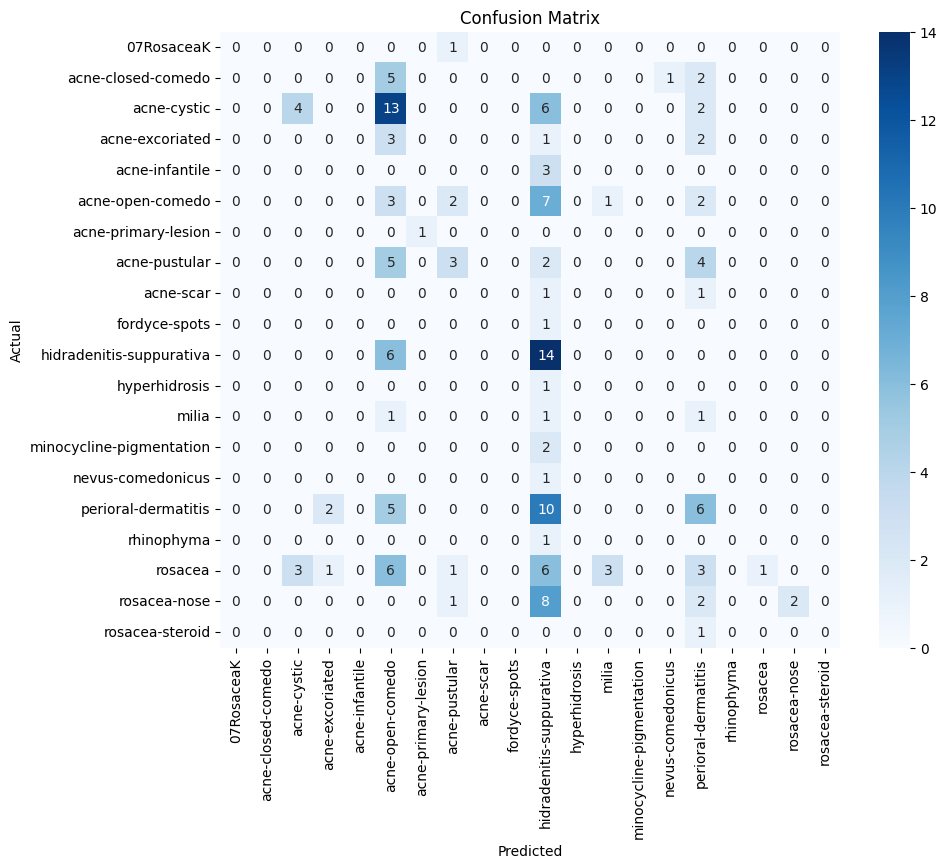

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title('Confusion Matrix')
plt.show()

In [19]:
# Save model and label encoder classes
model.save('/content/skinsense_model_v2.h5')
np.save('/content/label_classes.npy', le.classes_)
print("Model saved!")

# Prediction function
def predict_skin_condition(img_array):
    img_resized = cv2.resize(img_array, (64, 64))
    img_normalized = img_resized.reshape(1, 64, 64, 3) / 255.0
    pred = model.predict(img_normalized)
    class_idx = np.argmax(pred)
    confidence = np.max(pred) * 100
    return le.classes_[class_idx], confidence

# Test on one sample
sample_img = (X_test[0] * 255).astype(np.uint8)
result, conf = predict_skin_condition(sample_img)
print(f"Predicted: {result} ({conf:.2f}% confidence)")

Model saved!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: acne-open-comedo (46.27% confidence)


In [20]:
from google.colab import files
files.download('/content/skinsense_model_v2.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
!pip install gradio -q
import gradio as gr
from PIL import Image

def predict_from_image(img):
    img_array = np.array(img.resize((64, 64)))
    if img_array.shape[-1] == 4:  # remove alpha channel if present
        img_array = img_array[:, :, :3]
    result, conf = predict_skin_condition(img_array)
    return f"{result} ({conf:.2f}% confidence)"

demo = gr.Interface(
    fn=predict_from_image,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="SkinSense v2 - Skin Disease Detector",
    description=f"Detects {num_classes} skin conditions from images"
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://596ace8c70551353f1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [23]:
from google.colab import files
files.download('/content/skinsense_model_v2.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>